In [164]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [165]:
# Load the dataset
df = pd.read_csv('smartphone_de.csv')

# Check the first few rows
print(df)

                          Timestamp           Full Name : Gender :  \
0    2023/02/17 2:21:53 PM GMT+5:30  Dabbeta Ganesh Kumar     MALE   
1    2023/02/24 4:28:34 PM GMT+5:30     Mir Junaid Rasool     MALE   
2    2023/02/24 4:34:02 PM GMT+5:30                   Dev     MALE   
3    2023/02/27 3:32:22 PM GMT+5:30          A.RuthvikDev     MALE   
4    2023/02/27 3:33:44 PM GMT+5:30               Vishnu      MALE   
..                              ...                   ...      ...   
496  2023/03/28 2:36:46 PM GMT+5:30               Sahadev     MALE   
497  2023/03/28 2:37:54 PM GMT+5:30               Chandra     MALE   
498  2023/03/28 2:38:26 PM GMT+5:30                Laxman     MALE   
499  2023/03/28 2:39:19 PM GMT+5:30           Sheri mohan     MALE   
500  2023/03/28 2:39:59 PM GMT+5:30        Puri jaganath      MALE   

    Do you use your phone to click pictures of class notes?  \
0                                                  Yes        
1                                

In [166]:
print(df.isnull().sum())

Timestamp                                                                       0
Full Name :                                                                     0
Gender :                                                                        0
Do you use your phone to click pictures of class notes?                         0
Do you buy books/access books from your mobile?                                 0
Does your phone's battery last a day?                                           0
When your phone's battery dies out, do you run for the charger?                 0
Do you worry about losing your cell phone?                                      0
Do you take your phone to the bathroom?                                         0
Do you use your phone in any social gathering (parties)?                        0
Do you often check your phone without any notification?                         0
Do you check your phone just before going to sleep/just after waking up?        0
Do you keep your

In [167]:
print(df.columns)

Index(['Timestamp', 'Full Name :', 'Gender :',
       'Do you use your phone to click pictures of class notes?',
       'Do you buy books/access books from your mobile?',
       'Does your phone's battery last a day?',
       'When your phone's battery dies out, do you run for the charger?',
       'Do you worry about losing your cell phone?',
       'Do you take your phone to the bathroom?',
       'Do you use your phone in any social gathering (parties)?',
       'Do you often check your phone without any notification? ',
       'Do you check your phone just before going to sleep/just after waking up?',
       'Do you keep your phone right next to you while sleeping?',
       'Do you check emails, missed calls, texts during class time? ',
       'Do you find yourself relying on your phone when things get awkward?',
       'Are you on your phone while watching TV or eating food?',
       'Do you have a panic attack if you leave your phone elsewhere?',
       'You don't mind responding

In [168]:
df.fillna(method='ffill', inplace=True)

C:\Users\ELCOT\AppData\Local\Temp\ipykernel_8680\3970806690.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [169]:
print(df['Gender :'].unique())


['MALE' 'Prefer not to say' 'Female' 'yes ']


In [170]:
# Step 1: Strip whitespace and standardize the case
df['Gender :'] = df['Gender :'].str.strip().str.capitalize()

# Step 2: Map correct gender values and handle others
df['Gender :'] = df['Gender :'].replace({
    'Male': 'Male',
    'Female': 'Female',
    'MALE': 'Male',  # Correcting case sensitivity
    'Yes': 'Other',  # 'yes' is likely a misentry, categorize as 'Other'
    'Prefer not to say': 'Other'  # Group non-disclosure as 'Other'
})

# Check the unique values after cleaning
print(df['Gender :'].unique())


['Male' 'Other' 'Female']


In [171]:
print(df['whether you are addicted to phone?'].unique())

['yes' 'Yes' 'No' 'yes ']


In [172]:
# List of columns to clean and standardize
columns_to_clean = [
    'Do you take your phone to the bathroom?',
    'Do you use your phone in any social gathering (parties)?',
    'Do you often check your phone without any notification? ',
    'Do you check your phone just before going to sleep/just after waking up?',
    'Do you keep your phone right next to you while sleeping?',
    'Do you check emails, missed calls, texts during class time? ',
    'Do you find yourself relying on your phone when things get awkward?',
    'Are you on your phone while watching TV or eating food?',
    'Do you have a panic attack if you leave your phone elsewhere?',
    'You don\'t mind responding to messages or checking your phone while on date? ',
    'Can you live a day without phone ? ',
    'whether you are addicted to phone?'
]


In [173]:
# Function to clean and standardize text data
def clean_and_standardize(column):
    return column.str.strip().str.capitalize()

# Apply the cleaning function to each column
for column in columns_to_clean:
    df[column] = clean_and_standardize(df[column])

# Check unique values after cleaning
for column in columns_to_clean:
    print(f"Unique values for column '{column}':")
    print(df[column].unique())
    print()


Unique values for column 'Do you take your phone to the bathroom?':
['Yes' 'No']

Unique values for column 'Do you use your phone in any social gathering (parties)?':
['Yes' 'No']

Unique values for column 'Do you often check your phone without any notification? ':
['Yes' 'No']

Unique values for column 'Do you check your phone just before going to sleep/just after waking up?':
['Yes' 'No']

Unique values for column 'Do you keep your phone right next to you while sleeping?':
['Yes' 'No']

Unique values for column 'Do you check emails, missed calls, texts during class time? ':
['Yes' 'No']

Unique values for column 'Do you find yourself relying on your phone when things get awkward?':
['Yes' 'No']

Unique values for column 'Are you on your phone while watching TV or eating food?':
['Yes' 'No']

Unique values for column 'Do you have a panic attack if you leave your phone elsewhere?':
['Yes' 'No']

Unique values for column 'You don't mind responding to messages or checking your phone whil

Feature Creation

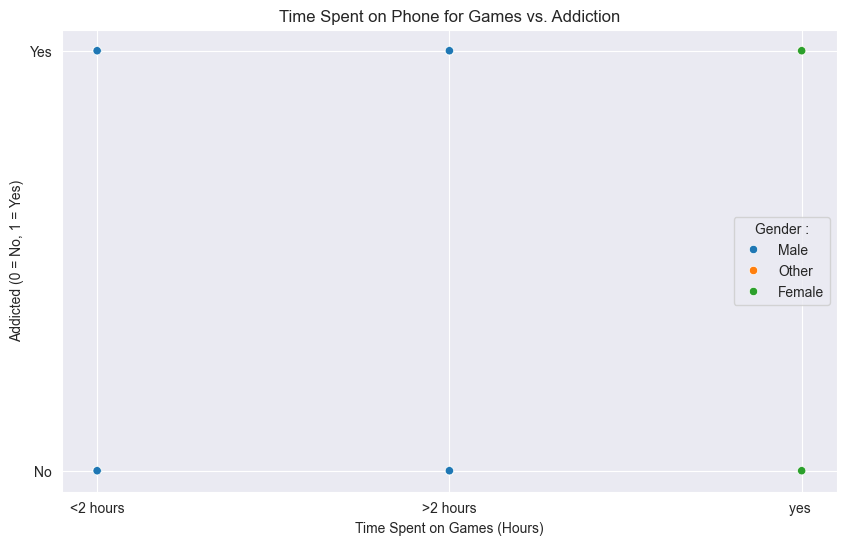

In [174]:
# Assuming 'For how long do you use your phone for playing games?' is in hours
plt.figure(figsize=(10, 6))
sns.scatterplot(x='For how long do you use your phone for playing games?', y='whether you are addicted to phone?', data=df, hue='Gender :', sizes=(20, 200))
plt.title('Time Spent on Phone for Games vs. Addiction')
plt.xlabel('Time Spent on Games (Hours)')
plt.ylabel('Addicted (0 = No, 1 = Yes)')
plt.show()

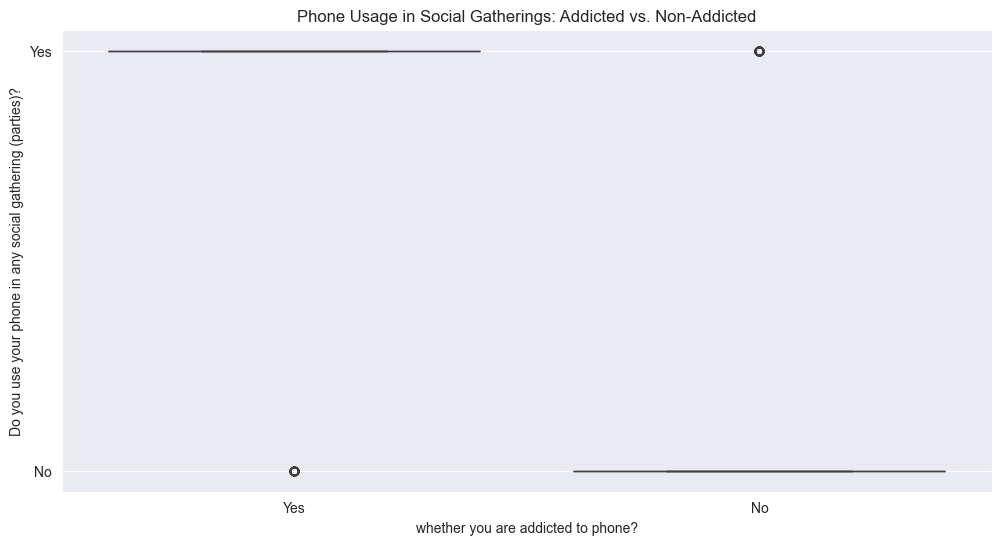

In [175]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='whether you are addicted to phone?', y='Do you use your phone in any social gathering (parties)?', data=df)
plt.title('Phone Usage in Social Gatherings: Addicted vs. Non-Addicted')
plt.show()


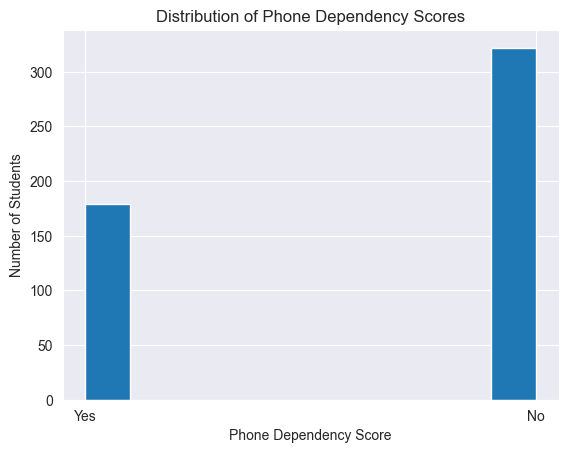

In [176]:
df['whether you are addicted to phone?'].hist(bins=10)
plt.title('Distribution of Phone Dependency Scores')
plt.xlabel('Phone Dependency Score')
plt.ylabel('Number of Students')
plt.show()


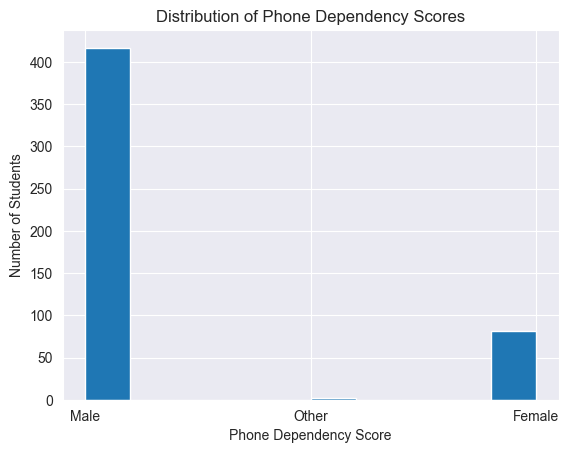

In [177]:
df['Gender :'].hist(bins=10)
plt.title('Distribution of Phone Dependency Scores')
plt.xlabel('Phone Dependency Score')
plt.ylabel('Number of Students')
plt.show()


In [178]:
df['Gender :'] = df['Gender :'].map({'Male': 0, 'Female': 1,'Other':2})  # Example encoding


In [179]:
df.drop(['Timestamp', 'Full Name :'], axis=1, inplace=True)


In [180]:
# Display the processed DataFrame
print(df.head())

   Gender : Do you use your phone to click pictures of class notes?  \
0         0                                                Yes        
1         0                                                Yes        
2         0                                                Yes        
3         0                                                Yes        
4         0                                                Yes        

  Do you buy books/access books from your mobile?  \
0                                             Yes   
1                                              No   
2                                              No   
3                                              No   
4                                             Yes   

  Does your phone's battery last a day?  \
0                                   Yes   
1                                   Yes   
2                                    No   
3                                   Yes   
4                                   Yes

In [181]:
# Inspect unique values
print(df["When your phone's battery dies out, do you run for the charger?"].unique())

# Clean and standardize the responses
df["When your phone's battery dies out, do you run for the charger?"] = df[
    "When your phone's battery dies out, do you run for the charger?"
].str.strip().replace({
    'Yes;No': 'Yes',  # Treat mixed responses as 'Yes' or choose an appropriate label
    'Yes': 'Yes',
    'No': 'No',
    '': 'No'  # Handle empty strings or NaN values if necessary
})

# Check unique values after cleaning
print(df["When your phone's battery dies out, do you run for the charger?"].unique())


['Yes;No' 'Yes' 'No' 'yes ']
['Yes' 'No' 'yes']


In [182]:
# Iterate over all columns and print unique values for each
for column in df.columns:
    print(f"Unique values for column '{column}':")
    print(df[column].unique())
    print()


Unique values for column 'Gender :':
[0 2 1]

Unique values for column 'Do you use your phone to click pictures of class notes?':
['Yes' 'No' 'yes ']

Unique values for column 'Do you buy books/access books from your mobile?':
['Yes' 'No' 'yes ']

Unique values for column 'Does your phone's battery last a day?':
['Yes' 'No' 'yes ']

Unique values for column 'When your phone's battery dies out, do you run for the charger?':
['Yes' 'No' 'yes']

Unique values for column 'Do you worry about losing your cell phone?':
['Yes' 'No' 'yes ']

Unique values for column 'Do you take your phone to the bathroom?':
['Yes' 'No']

Unique values for column 'Do you use your phone in any social gathering (parties)?':
['Yes' 'No']

Unique values for column 'Do you often check your phone without any notification? ':
['Yes' 'No']

Unique values for column 'Do you check your phone just before going to sleep/just after waking up?':
['Yes' 'No']

Unique values for column 'Do you keep your phone right next to you

In [183]:
# Clean and standardize the responses
df["Do you use your phone to click pictures of class notes?"] = df[
    "Do you use your phone to click pictures of class notes?"
].str.strip().str.capitalize()

# Check unique values after cleaning
print(df["Do you use your phone to click pictures of class notes?"].unique())


['Yes' 'No']


In [184]:
# Option 1: Fill missing values with a default value (e.g., 'No')
df["Do you use your phone to click pictures of class notes?"].fillna('No', inplace=True)

C:\Users\ELCOT\AppData\Local\Temp\ipykernel_8680\1359906600.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Do you use your phone to click pictures of class notes?"].fillna('No', inplace=True)


In [185]:
# Clean and standardize the responses
df["Do you buy books/access books from your mobile?"] = df[
    "Do you buy books/access books from your mobile?"
].str.strip().str.capitalize()

# Check unique values after cleaning
print(df["Do you buy books/access books from your mobile?"].unique())


['Yes' 'No']


In [186]:
# Option 1: Fill missing values with a default value (e.g., 'No')
df["Do you buy books/access books from your mobile?"].fillna('No', inplace=True)

C:\Users\ELCOT\AppData\Local\Temp\ipykernel_8680\2684303419.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Do you buy books/access books from your mobile?"].fillna('No', inplace=True)


In [187]:
# Apply label encoding
df["Does your phone's battery last a day?"] = df[
    "Does your phone's battery last a day?"
].map({'Yes': 1, 'No': 0})



In [188]:
df = pd.get_dummies(df, columns=["Does your phone's battery last a day?"], drop_first=True)

In [189]:
# Clean and standardize the responses
df['Do you worry about losing your cell phone?'] = df[
    'Do you worry about losing your cell phone?'
].str.strip().str.capitalize()

# Check unique values after cleaning
print(df['Do you worry about losing your cell phone?'].unique())

['Yes' 'No']


In [190]:
df['Do you worry about losing your cell phone?'].fillna('No', inplace=True)

C:\Users\ELCOT\AppData\Local\Temp\ipykernel_8680\2123276588.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Do you worry about losing your cell phone?'].fillna('No', inplace=True)


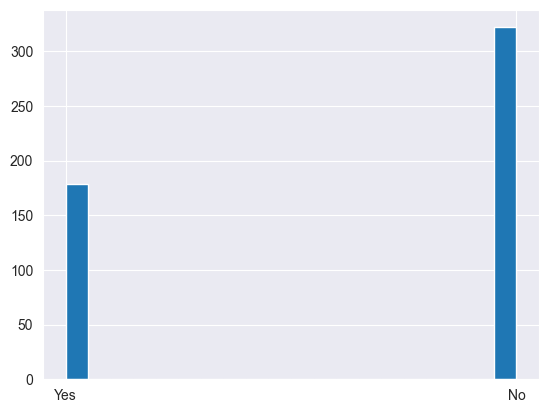

In [191]:




import seaborn as sns
import matplotlib.pyplot as plt

# Set Seaborn style
sns.set_style('darkgrid')

# Plotting the histogram
df['whether you are addicted to phone?'].hist(bins=20)
plt.show()

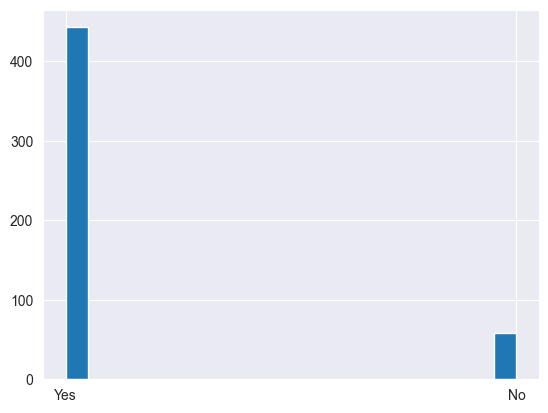

In [192]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set Seaborn style
sns.set_style('darkgrid')

# Plotting the histogram
df['Do you use your phone to click pictures of class notes?'].hist(bins=20)
plt.show()

In [193]:
# Fill missing values with a default value (e.g., 'No')
for column in columns_to_clean:
    df[column].fillna('No', inplace=True)

# Check if there are any remaining missing values
print(df.isnull().sum())


Gender :                                                                        0
Do you use your phone to click pictures of class notes?                         0
Do you buy books/access books from your mobile?                                 0
When your phone's battery dies out, do you run for the charger?                 0
Do you worry about losing your cell phone?                                      0
Do you take your phone to the bathroom?                                         0
Do you use your phone in any social gathering (parties)?                        0
Do you often check your phone without any notification?                         0
Do you check your phone just before going to sleep/just after waking up?        0
Do you keep your phone right next to you while sleeping?                        0
Do you check emails, missed calls, texts during class time?                     0
Do you find yourself relying on your phone when things get awkward?             0
Are you on your 

C:\Users\ELCOT\AppData\Local\Temp\ipykernel_8680\2659867866.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna('No', inplace=True)


In [194]:
columns_to_convert = df.columns

# Clean and standardize the responses
df = df.apply(lambda col: col.str.strip().str.capitalize() if col.dtype == 'object' else col)

# Convert categorical variables to numerical values
for column in columns_to_convert:
    if df[column].dtype == 'object':
        df[column] = df[column].astype('category').cat.codes

# Display the first few rows of the modified DataFrame
print(df.head())

   Gender :  Do you use your phone to click pictures of class notes?  \
0         0                                                  1         
1         0                                                  1         
2         0                                                  1         
3         0                                                  1         
4         0                                                  1         

   Do you buy books/access books from your mobile?  \
0                                                1   
1                                                0   
2                                                0   
3                                                0   
4                                                1   

   When your phone's battery dies out, do you run for the charger?  \
0                                                  1                 
1                                                  1                 
2                               

In [195]:
print(df["For how long do you use your phone for playing games?"])

0      0
1      0
2      1
3      0
4      0
      ..
496    0
497    1
498    1
499    1
500    1
Name: For how long do you use your phone for playing games?, Length: 501, dtype: int8


In [196]:
df["Does your phone's battery last a day?_1.0"] = df["Does your phone's battery last a day?_1.0"].astype(int)


In [197]:
from imblearn.over_sampling import RandomOverSampler
from collections import Counter
import pandas as pd

# Assuming df is your DataFrame and 'whether you are addicted to phone?' is the target column
X = df.drop(columns=['whether you are addicted to phone?'])
y = df['whether you are addicted to phone?']

# Before oversampling
print("Before oversampling:", Counter(y))

# Initialize the RandomOverSampler
ros = RandomOverSampler(random_state=42)

# Fit and resample the dataset
X_resampled, y_resampled = ros.fit_resample(X, y)

# After oversampling
print("After oversampling:", Counter(y_resampled))

# Convert resampled data back to a DataFrame
df_resampled = pd.concat([X_resampled, y_resampled], axis=1)


Before oversampling: Counter({0: 322, 1: 179})
After oversampling: Counter({1: 322, 0: 322})


In [198]:
df['whether you are addicted to phone?'].value_counts()

whether you are addicted to phone?
0    322
1    179
Name: count, dtype: int64

In [199]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled ,  y_resampled, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [200]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Define the base models
level0 = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('svc', SVC(kernel='linear', probability=True, random_state=42)),
    ('xgb', xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)),
    ('knn', KNeighborsClassifier())
]

# Define the meta-model
level1 = LogisticRegression()

# Create the stacking ensemble
stacking_model = StackingClassifier(estimators=level0, final_estimator=level1, cv=5)

# Train the stacking ensemble
stacking_model.fit(X_resampled, y_resampled)

# Make predictions
train_predictions = stacking_model.predict(X_resampled)  # Predictions on the training set
test_predictions = stacking_model.predict(X_test)       # Predictions on the test set

# Evaluate the stacking model on the training set
print("Stacking Model Training Classification Report:")
print(classification_report(y_resampled, train_predictions))

print("Stacking Model Training Confusion Matrix:")
print(confusion_matrix(y_resampled, train_predictions))

print(f"Stacking Model Training Accuracy: {accuracy_score(y_resampled, train_predictions):.2f}")

# Evaluate the stacking model on the test set
print("Stacking Model Test Classification Report:")
print(classification_report(y_test, test_predictions))

print("Stacking Model Test Confusion Matrix:")
print(confusion_matrix(y_test, test_predictions))

print(f"Stacking Model Test Accuracy: {accuracy_score(y_test, test_predictions):.2f}")


c:\Users\ELCOT\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:33:28] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\ELCOT\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:33:33] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\ELCOT\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:33:34] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are

Stacking Model Training Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       322
           1       1.00      1.00      1.00       322

    accuracy                           1.00       644
   macro avg       1.00      1.00      1.00       644
weighted avg       1.00      1.00      1.00       644

Stacking Model Training Confusion Matrix:
[[322   0]
 [  1 321]]
Stacking Model Training Accuracy: 1.00
Stacking Model Test Classification Report:
              precision    recall  f1-score   support

           0       0.88      1.00      0.94        59
           1       1.00      0.89      0.94        70

    accuracy                           0.94       129
   macro avg       0.94      0.94      0.94       129
weighted avg       0.95      0.94      0.94       129

Stacking Model Test Confusion Matrix:
[[59  0]
 [ 8 62]]
Stacking Model Test Accuracy: 0.94


In [201]:
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Define and train the CatBoost model
catboost_model = CatBoostClassifier(learning_rate=0.1, depth=6, iterations=1000, random_state=42, silent=True)
catboost_model.fit(X_resampled, y_resampled)

# Make predictions
train_predictions = catboost_model.predict(X_resampled)  # Predictions on the training set
test_predictions = catboost_model.predict(X_test)       # Predictions on the test set

# Evaluate the CatBoost model on the training set
print("CatBoost Training Classification Report:")
print(classification_report(y_resampled, train_predictions))

print("CatBoost Training Confusion Matrix:")
print(confusion_matrix(y_resampled, train_predictions))

print(f"CatBoost Training Accuracy: {accuracy_score(y_resampled, train_predictions) * 100:.2f}%")

# Evaluate the CatBoost model on the test set
print("CatBoost Test Classification Report:")
print(classification_report(y_test, test_predictions))

print("CatBoost Test Confusion Matrix:")
print(confusion_matrix(y_test, test_predictions))

print(f"CatBoost Test Accuracy: {accuracy_score(y_test, test_predictions) * 100:.2f}%")


CatBoost Training Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       322
           1       1.00      1.00      1.00       322

    accuracy                           1.00       644
   macro avg       1.00      1.00      1.00       644
weighted avg       1.00      1.00      1.00       644

CatBoost Training Confusion Matrix:
[[322   0]
 [  1 321]]
CatBoost Training Accuracy: 99.84%
CatBoost Test Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96        59
           1       0.97      0.96      0.96        70

    accuracy                           0.96       129
   macro avg       0.96      0.96      0.96       129
weighted avg       0.96      0.96      0.96       129

CatBoost Test Confusion Matrix:
[[57  2]
 [ 3 67]]
CatBoost Test Accuracy: 96.12%


In [202]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Define and train the Extra Trees model
et_model = ExtraTreesClassifier(n_estimators=100, random_state=42)
et_model.fit(X_resampled, y_resampled)

# Make predictions
train_predictions = et_model.predict(X_resampled)  # Predictions on the training set
test_predictions = et_model.predict(X_test)       # Predictions on the test set

# Evaluate the Extra Trees model on the training set
print("Extra Trees Training Classification Report:")
print(classification_report(y_resampled, train_predictions))

print("Extra Trees Training Confusion Matrix:")
print(confusion_matrix(y_resampled, train_predictions))

print(f"Extra Trees Training Accuracy: {accuracy_score(y_resampled, train_predictions) * 100:.2f}%")

# Evaluate the Extra Trees model on the test set
print("Extra Trees Test Classification Report:")
print(classification_report(y_test, test_predictions))

print("Extra Trees Test Confusion Matrix:")
print(confusion_matrix(y_test, test_predictions))

print(f"Extra Trees Test Accuracy: {accuracy_score(y_test, test_predictions) * 100:.2f}%")


Extra Trees Training Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       322
           1       1.00      1.00      1.00       322

    accuracy                           1.00       644
   macro avg       1.00      1.00      1.00       644
weighted avg       1.00      1.00      1.00       644

Extra Trees Training Confusion Matrix:
[[322   0]
 [  1 321]]
Extra Trees Training Accuracy: 99.84%
Extra Trees Test Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        59
           1       1.00      1.00      1.00        70

    accuracy                           1.00       129
   macro avg       1.00      1.00      1.00       129
weighted avg       1.00      1.00      1.00       129

Extra Trees Test Confusion Matrix:
[[59  0]
 [ 0 70]]
Extra Trees Test Accuracy: 100.00%


c:\Users\ELCOT\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but ExtraTreesClassifier was fitted with feature names
  warnings.warn(


Visualization

c:\Users\ELCOT\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\ELCOT\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
c:\Users\ELCOT\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


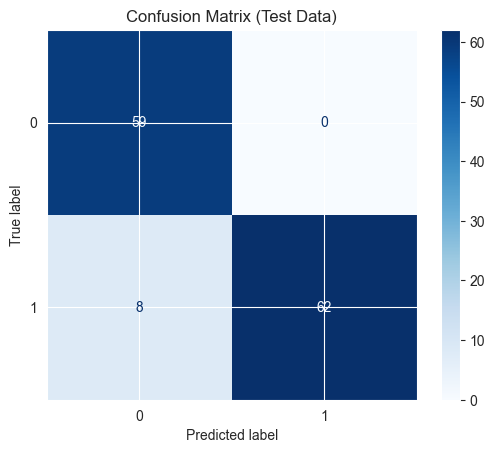

In [203]:
# Confusion Matrix Heatmaps
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc, precision_recall_curve

ConfusionMatrixDisplay.from_estimator(stacking_model, X_test, y_test, cmap='Blues')
plt.title('Confusion Matrix (Test Data)')
plt.show()

c:\Users\ELCOT\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\ELCOT\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
c:\Users\ELCOT\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


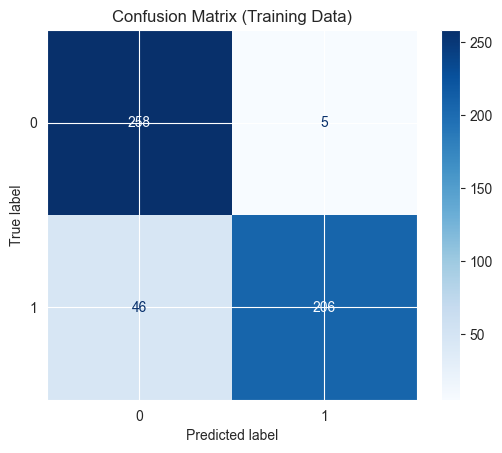

In [204]:

ConfusionMatrixDisplay.from_estimator(stacking_model, X_train, y_train, cmap='Blues')
plt.title('Confusion Matrix (Training Data)')
plt.show()

c:\Users\ELCOT\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\ELCOT\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
c:\Users\ELCOT\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


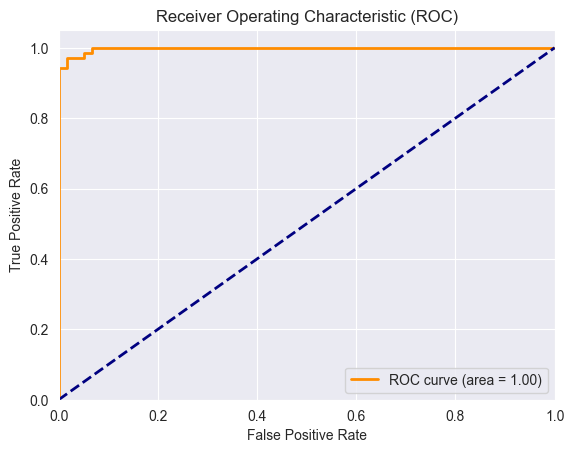

In [205]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, stacking_model.predict_proba(X_test)[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()

c:\Users\ELCOT\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\ELCOT\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
c:\Users\ELCOT\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


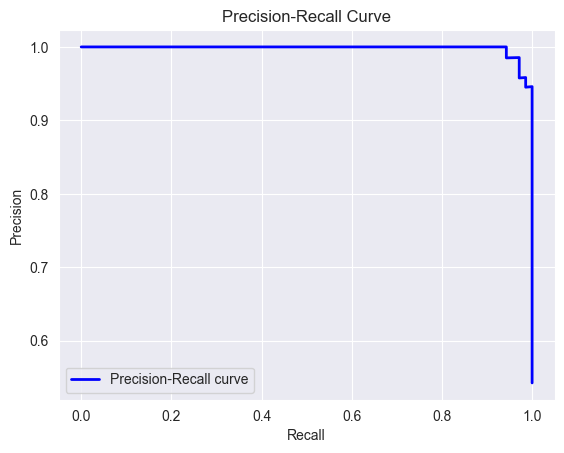

In [206]:
# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, stacking_model.predict_proba(X_test)[:, 1])

plt.figure()
plt.plot(recall, precision, color='blue', lw=2, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.show()

In [207]:
import pickle

pickle.dump(stacking_model,open('stacking.pkl','wb'))
stacking_model = pickle.load(open('stacking.pkl','rb'))

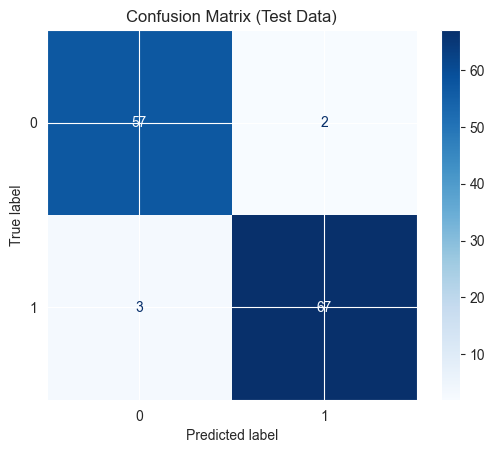

In [208]:
# Confusion Matrix Heatmaps
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc, precision_recall_curve

ConfusionMatrixDisplay.from_estimator(catboost_model, X_test, y_test, cmap='Blues')
plt.title('Confusion Matrix (Test Data)')
plt.show()

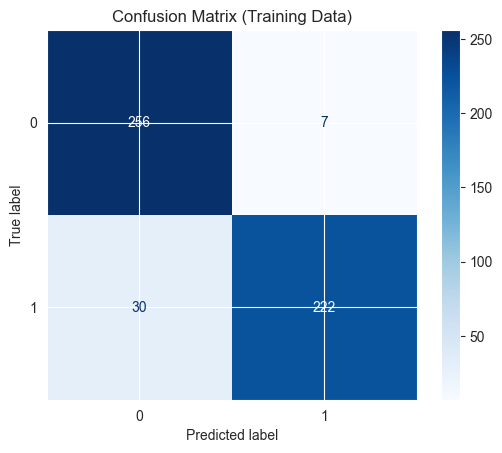

In [209]:

ConfusionMatrixDisplay.from_estimator(catboost_model, X_train, y_train, cmap='Blues')
plt.title('Confusion Matrix (Training Data)')
plt.show()

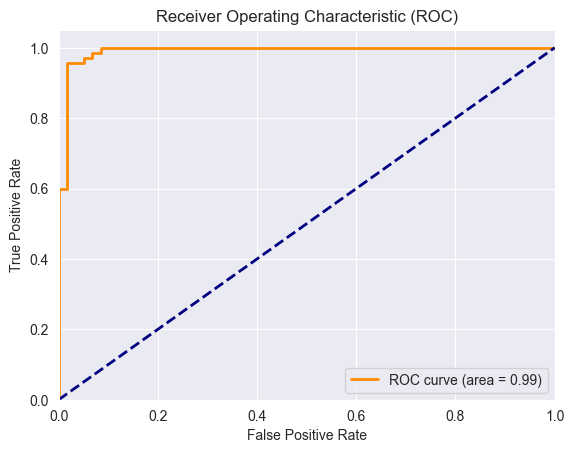

In [210]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, catboost_model.predict_proba(X_test)[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()

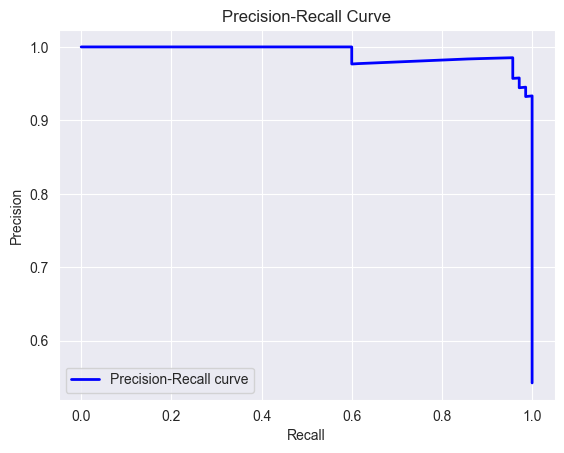

In [211]:
# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, catboost_model.predict_proba(X_test)[:, 1])

plt.figure()
plt.plot(recall, precision, color='blue', lw=2, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.show()

In [220]:
import pickle

pickle.dump(catboost_model,open('catboost.pkl','wb'))
catboost_model = pickle.load(open('catboost.pkl','rb'))

c:\Users\ELCOT\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but ExtraTreesClassifier was fitted with feature names
  warnings.warn(


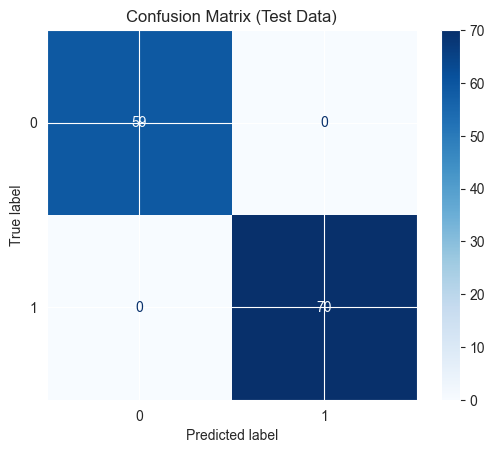

In [213]:
# Confusion Matrix Heatmaps
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc, precision_recall_curve

ConfusionMatrixDisplay.from_estimator(et_model, X_test, y_test, cmap='Blues')
plt.title('Confusion Matrix (Test Data)')
plt.show()

c:\Users\ELCOT\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but ExtraTreesClassifier was fitted with feature names
  warnings.warn(


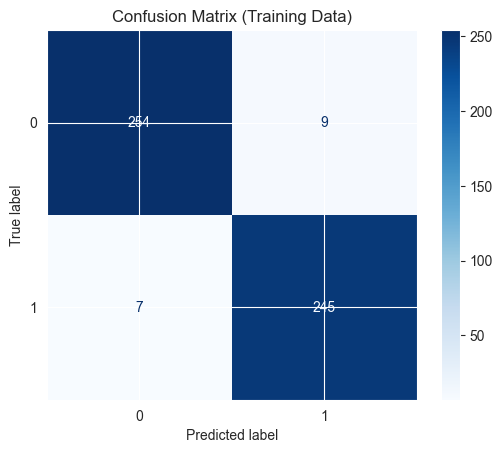

In [214]:

ConfusionMatrixDisplay.from_estimator(et_model, X_train, y_train, cmap='Blues')
plt.title('Confusion Matrix (Training Data)')
plt.show()

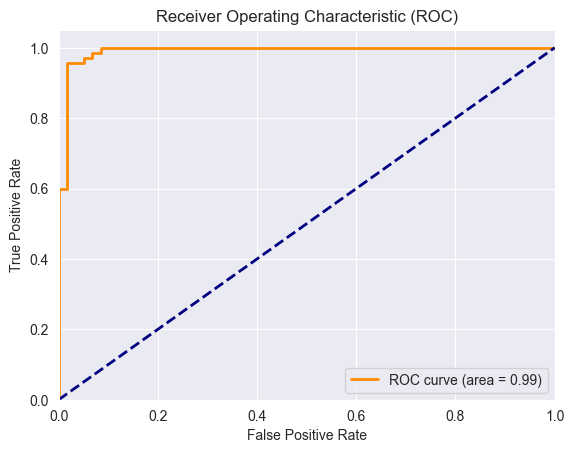

In [215]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, catboost_model.predict_proba(X_test)[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()

c:\Users\ELCOT\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but ExtraTreesClassifier was fitted with feature names
  warnings.warn(


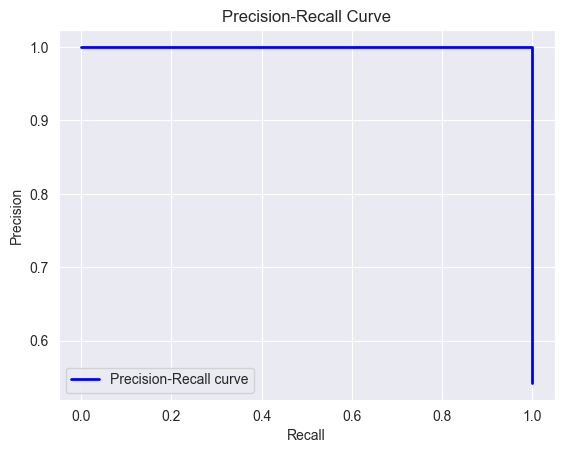

In [216]:
# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, et_model.predict_proba(X_test)[:, 1])

plt.figure()
plt.plot(recall, precision, color='blue', lw=2, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.show()

In [221]:
import pickle

pickle.dump(et_model,open('et_model.pkl','wb'))
et_model = pickle.load(open('et_model.pkl','rb'))

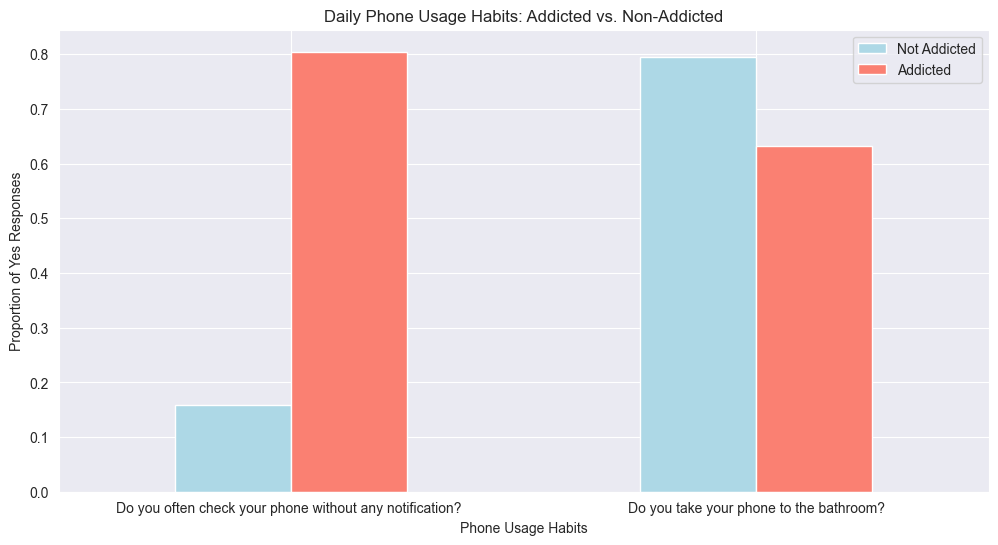

In [217]:
# Example of a grouped bar chart
habits = ['Do you often check your phone without any notification? ', 'Do you take your phone to the bathroom?']
habit_data = df.groupby('whether you are addicted to phone?')[habits].mean().transpose()

habit_data.plot(kind='bar', figsize=(12, 6), color=['lightblue', 'salmon'])
plt.title('Daily Phone Usage Habits: Addicted vs. Non-Addicted')
plt.ylabel('Proportion of Yes Responses')
plt.xlabel('Phone Usage Habits')
plt.xticks(rotation=0)
plt.legend(['Not Addicted', 'Addicted'])
plt.show()


Plot Bar Chart for Accuracy Comparison

c:\Users\ELCOT\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\ELCOT\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
c:\Users\ELCOT\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
c:\Users\ELCOT\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but ExtraTreesClassifier was fitted with feature names
  warnings.warn(
C:\Users\ELCOT\AppData\Local\Temp\ipykernel_8680\86965205.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be r

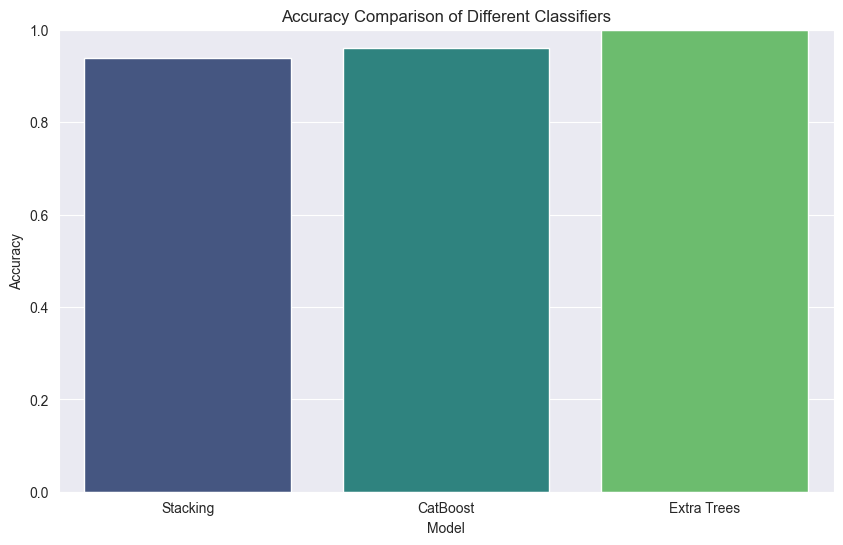

In [218]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
stacking_test_predictions = stacking_model.predict(X_test)
catboost_test_predictions = catboost_model.predict(X_test)
et_test_predictions = et_model.predict(X_test)

accuracies = {
    'Stacking': accuracy_score(y_test, stacking_test_predictions),
    'CatBoost': accuracy_score(y_test, catboost_test_predictions),
    'Extra Trees': accuracy_score(y_test, et_test_predictions)
}

# Create a DataFrame for plotting
import pandas as pd
accuracy_df = pd.DataFrame(list(accuracies.items()), columns=['Model', 'Accuracy'])

# Plot the accuracies
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=accuracy_df, palette="viridis")
plt.title("Accuracy Comparison of Different Classifiers")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()


In [219]:
df

,Gender :,Do you use your phone to click pictures of class notes?,Do you buy books/access books from your mobile?,"When your phone's battery dies out, do you run for the charger?",Do you worry about losing your cell phone?,Do you take your phone to the bathroom?,Do you use your phone in any social gathering (parties)?,Do you often check your phone without any notification?,Do you check your phone just before going to sleep/just after waking up?,Do you keep your phone right next to you while sleeping?,"Do you check emails, missed calls, texts during class time?",Do you find yourself relying on your phone when things get awkward?,Are you on your phone while watching TV or eating food?,Do you have a panic attack if you leave your phone elsewhere?,You don't mind responding to messages or checking your phone while on date?,For how long do you use your phone for playing games?,Can you live a day without phone ?,whether you are addicted to phone?,Does your phone's battery last a day?_1.0
0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,1,1
1,0,1,0,1,1,1,1,1,1,1,0,1,0,1,1,0,0,1,1
2,0,1,0,1,1,1,1,1,1,1,0,1,1,1,1,1,0,1,0
3,0,1,0,1,1,0,1,1,1,1,1,1,0,1,0,0,1,0,1
4,0,1,1,1,1,0,1,1,1,1,0,0,0,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496,0,0,0,1,0,0,0,0,1,1,0,0,1,1,0,0,1,0,0
497,0,1,0,1,0,1,1,1,1,1,1,0,1,1,1,1,1,0,1
498,0,0,0,1,1,0,1,1,0,0,1,0,1,0,1,1,1,1,1
499,0,1,1,1,0,1,1,0,1,1,0,1,1,0,1,1,1,0,0
